In [1]:
from optimality import Optimality
import numpy as np
from task import probabilistic_task

np.random.seed(0)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [2]:
## time estimation
from tqdm import tqdm
import time
import torch

all_times = []

opt = Optimality(
    probabilistic_task(),
)

for i_agent in tqdm(range(30)):

    np.random.seed(i_agent)
    torch.manual_seed(i_agent)
    opt.env.generate_test_task(num_tasks=100, num_trials=500)
    start_time = time.time()
    _ = opt.infer(nb_particles=100)
    end_time = time.time()
    all_times.append(end_time - start_time)

print(f"Time taken: mean {np.mean(all_times)} seconds, std {np.std(all_times)} seconds")

100%|██████████| 30/30 [6:06:15<00:00, 732.51s/it]

Time taken: mean 731.5683931032817 seconds, std 116.42832078932523 seconds


In [2]:
self = Optimality(
    probabilistic_task(),
)

In [28]:
import numpy as np
from tqdm import tqdm

# Define the parameter ranges
#range_of_vols = [0.05, 0.1, 0.15, 0.2, 0.25]
#range_of_taus = [0.0, 0.01]
#range_of_ffs = [0.1, 0.15, 0.2, 0.25, 0.3]

range_of_vols = [0.1, 0.15, 0.2, 0.25, 0.3]
range_of_taus = [0.0]
range_of_ffs = [0.05]

nb_tasks = 200
vols_grid, ffs_grid, taus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_taus, indexing='ij')
vols, ffs, taus = vols_grid.ravel(), ffs_grid.ravel(), taus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
taus = np.tile(taus, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

In [29]:
nb_agents = 30
nb_trials = 500
nb_simuls = nb_tasks
performances = np.zeros((nb_agents, 3))
rewards = np.zeros((nb_agents, 3))
probas_association = np.zeros((nb_agents, nb_tasks, nb_trials, 4))
probas_vols = np.zeros((nb_agents, nb_tasks, nb_trials))
probas_transition = np.zeros((nb_agents, nb_tasks, nb_trials))

performances_nb_cues = np.zeros((nb_agents, 3, 4))
rewards_nb_cues = np.zeros((nb_agents, 3, 4))

for i_agent in tqdm(range(nb_agents)):

    np.random.seed(i_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=nb_trials, num_steps=5, taus=taus, variable_length=False, nus=vols, ffs=ffs)

    all_map_particles, prediction_weather, association_probs_trials, polarity_particles, false_positive_rate_particles = self.infer(
        nb_particles=100, gamma=0.5
    )
    probas_transition[i_agent] = all_map_particles[:,:, 3].T

  0%|          | 0/30 [02:35<?, ?it/s]


KeyboardInterrupt: 

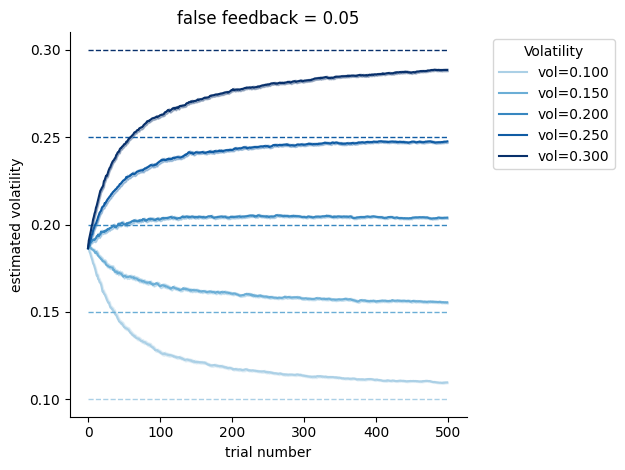

In [ ]:
unique_vols = np.unique(vols)
estimations_means = np.hstack([probas_transition[:, (vols==v)].mean(axis=1, keepdims=True) for v in unique_vols])

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create a colormap with as many shades as unique_vols
cmap = plt.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white

fig, ax = plt.subplots()
for i in range(estimations_means.shape[1]):
    color = cmap(i + 2)  # skip the lightest colors
    ax.plot(estimations_means[:, i, 1:nb_trials].mean(axis=0), color=color, label=f'vol={unique_vols[i]:.3f}')
    ax.fill_between(np.arange(1, nb_trials), 
        estimations_means[:, i, 1:nb_trials].mean(axis=0) - estimations_means[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:nb_trials].mean(axis=0) + estimations_means[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    ax.plot([0, nb_trials], [unique_vols[i], unique_vols[i]], color=color, linestyle='--', linewidth=1)
ax.set_xlabel('True volatility')
ax.legend(title="Volatility", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('trial number')
ax.set_ylabel('estimated volatility')
ax.set_title('false feedback = 0.05')
ax.set_yticks(unique_vols)
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('figures/volatility_trial_number_april_2026_opt.pdf')

### False feedback

In [16]:
import numpy as np
from tqdm import tqdm

# Define the parameter ranges

range_of_vols = [0.05]
range_of_taus = [0.0]
range_of_ffs = [0.05, 0.1, 0.15, 0.2, 0.25]

nb_tasks = 200
vols_grid, ffs_grid, taus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_taus, indexing='ij')
vols, ffs, taus = vols_grid.ravel(), ffs_grid.ravel(), taus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
taus = np.tile(taus, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

In [ ]:
nb_agents = 30
nb_trials = 500
nb_simuls = nb_tasks
performances = np.zeros((nb_agents, 3))
rewards = np.zeros((nb_agents, 3))
probas_ffs = np.zeros((nb_agents, nb_tasks, nb_trials))

performances_nb_cues = np.zeros((nb_agents, 3, 4))
rewards_nb_cues = np.zeros((nb_agents, 3, 4))

for i_agent in tqdm(range(nb_agents)):

    np.random.seed(i_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=nb_trials, num_steps=5, taus=taus, variable_length=False, nus=vols, ffs=ffs)

    all_map_particles, prediction_weather, association_probs_trials, polarity_particles, false_positive_rate_particles = self.infer(
        nb_particles=100, gamma=0.5
    )
    probas_ffs[i_agent] = false_positive_rate_particles.T

100%|██████████| 30/30 [12:19:54<00:00, 1479.81s/it]


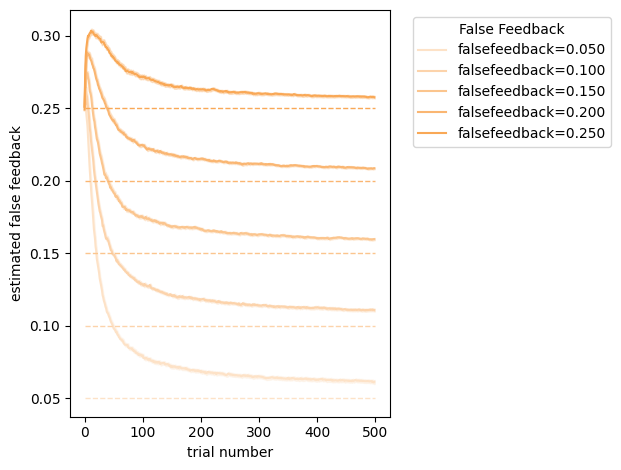

In [18]:
unique_falsefeedback = np.unique(ffs)
estimations_means = np.hstack([probas_ffs[:, (ffs==v) * (vols==0.05)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

for i in range(estimations_means.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means[:, i, 1:500].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.fill_between(np.arange(1, 500), 
        estimations_means[:, i, 1:].mean(axis=0) - estimations_means[:, i, 1:].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:].mean(axis=0) + estimations_means[:, i, 1:].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, 500], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
ax.set_title('vol = 0.05')
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/falsefeedback_trial_number_april_2026_optimal.pdf')

### With reversals and subjective

In [37]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))
itrial = 300

for idx_agent in range(nb_agents):
    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, taus=[0.0] * nb_simuls)
    initial_probas = self.env.probas.copy()
    np.random.seed(idx_agent)    
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, taus=[0.0] * nb_simuls)    
    all_map_particles, prediction_weather, association_probs_trials, polarity_particles, false_positive_rate_particles = self.infer(
        nb_particles=100, gamma=0.5
    )
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = 1 - np.swapaxes(association_probs_trials[np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    all_map_particles, prediction_weather, association_probs_trials, polarity_particles, false_positive_rate_particles = self.infer(
        nb_particles=100, gamma=0.5
    )
    association_probs_reversals[idx_agent] = 1 - np.swapaxes(association_probs_trials[np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(self.env.probas[np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)

Inferring: 100%|██████████| 500/500 [10:51<00:00,  1.30s/it]


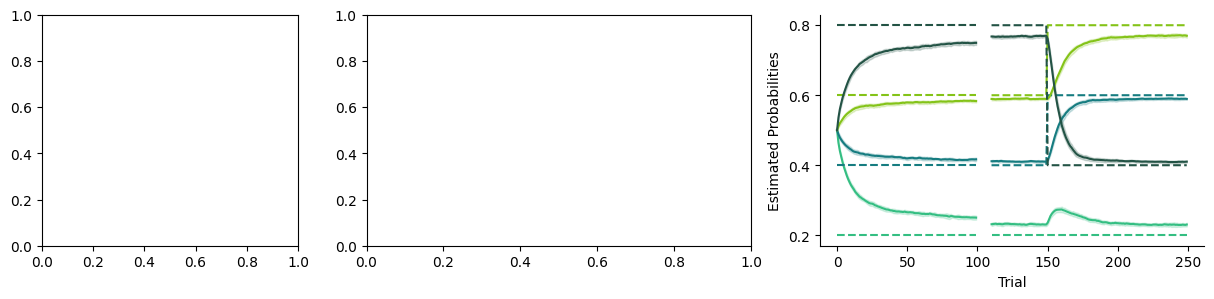

In [38]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})

# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs_reversals.mean(axis=0)[:100, i]
    pstd = association_probs_reversals.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])
axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/reversals_trial_number_april_2026_optimal_new.pdf')

plt.show()